In [1]:
import setup

In [2]:
import organizar as orgn, funcoes as fn, pandas as pd

laureados = orgn.laureados()
nobelPorNac = orgn.nobelPorNac(laureados)
democracias = orgn.democracias()
populacao = fn.extrairPopulacao()
correl = fn.correlDemocrNobel(laureados, democracias, populacao)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dfMulheres = laureados.query("genero == 'female'")

total = (
    laureados.groupby(["decada", "categoria"])
        .size()
        .rename("total")
)

mulheres = (
    dfMulheres.groupby(["decada", "categoria"])
        .size()
        .rename("mulheres")
)

participacao = pd.concat([total, mulheres], axis=1)

participacao = participacao.reset_index()

participacao["mulheres"] = participacao["mulheres"].fillna(0)

participacao["percentual"] = (
    participacao["mulheres"] /
    participacao["total"] * 100
)

participacao


,decada,categoria,total,mulheres,percentual
0,1900,Física,13,1.0,7.692308
1,1900,Literatura,10,1.0,10.000000
2,1900,Medicina,11,0.0,0.000000
3,1900,Paz,14,1.0,7.142857
4,1900,Química,9,0.0,0.000000
...,...,...,...,...,...
67,2020,Física,9,1.0,11.111111
68,2020,Literatura,3,2.0,66.666667
69,2020,Medicina,6,0.0,0.000000
70,2020,Paz,6,1.0,16.666667


In [17]:
orgn.mulheresPorCategoria(laureados)

,decada,categoria,total,mulheres,percentual
0,1900,Física,13,1.0,7.692308
1,1900,Literatura,10,1.0,10.000000
2,1900,Medicina,11,0.0,0.000000
3,1900,Paz,14,1.0,7.142857
4,1900,Química,9,0.0,0.000000
...,...,...,...,...,...
67,2020,Física,9,1.0,11.111111
68,2020,Literatura,3,2.0,66.666667
69,2020,Medicina,6,0.0,0.000000
70,2020,Paz,6,1.0,16.666667


In [5]:
dfMulheres = laureados.query("genero == 'female'")

total = (
    laureados.groupby("decada")
        .size()
        .rename("total")
)

mulheres = (
    dfMulheres.groupby("decada")
        .size()
        .rename("mulheres")
)

participacao_geral = pd.concat([total, mulheres], axis=1)

participacao_geral = participacao_geral.reset_index()

participacao_geral["mulheres"] = participacao_geral["mulheres"].fillna(0)

participacao_geral["percentual"] = (
    participacao_geral["mulheres"] /
    participacao_geral["total"] * 100
)

participacao_geral

,decada,total,mulheres,percentual
0,1900,57,3.0,5.263158
1,1910,40,1.0,2.500000
2,1920,54,2.0,3.703704
3,1930,56,3.0,5.357143
4,1940,43,3.0,6.976744
5,1950,72,0.0,0.000000
6,1960,79,3.0,3.797468
7,1970,104,4.0,3.846154
8,1980,97,4.0,4.123711
9,1990,104,7.0,6.730769


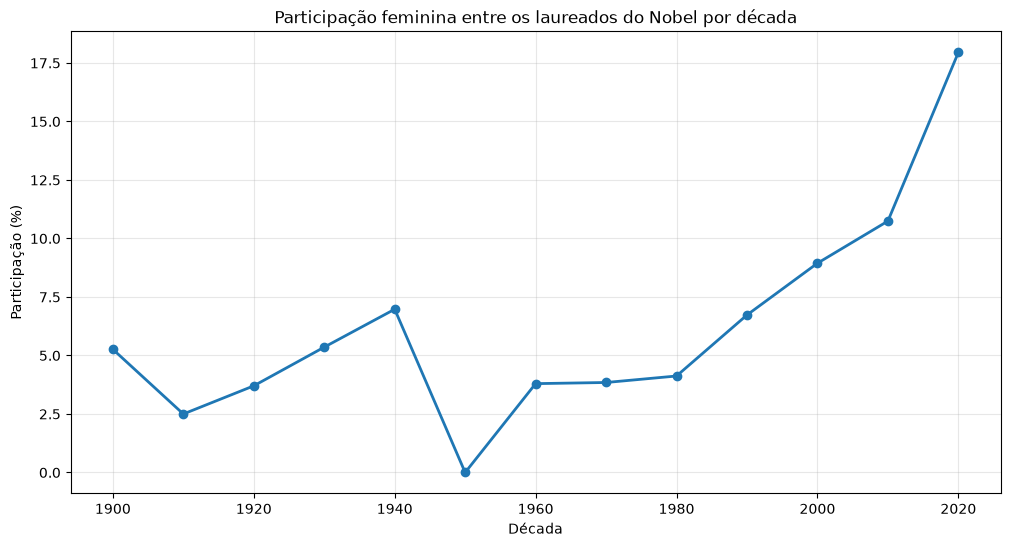

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    participacao_geral["decada"],
    participacao_geral["percentual"],
    marker="o",
    linewidth=2
)

plt.title("Participação feminina entre os laureados do Nobel por década")
plt.xlabel("Década")
plt.ylabel("Participação (%)")
plt.grid(alpha=0.3)

plt.show()

Text(0.5, 1.0, 'Participação feminina (%) por categoria')

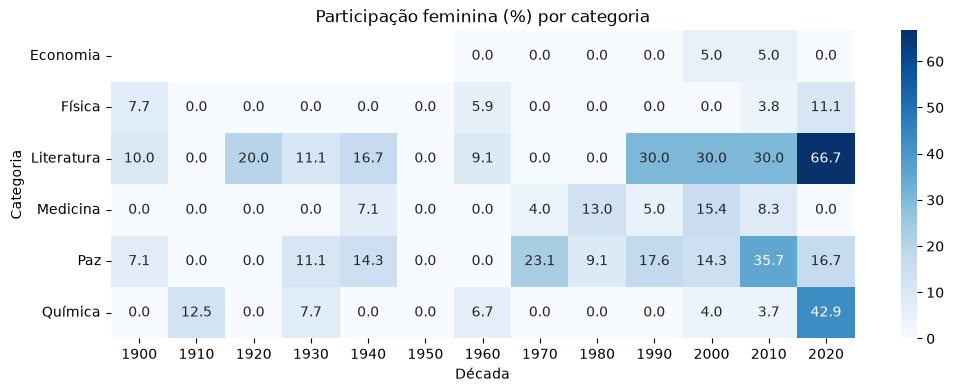

In [7]:
import seaborn as sns

heatmap = participacao.pivot(
    index="categoria",
    columns="decada",
    values="percentual"
)

plt.figure(figsize=(12,4))

sns.heatmap(
    heatmap,
    annot=True,
    cmap="Blues",
    fmt=".1f"
)

plt.xlabel("Década")
plt.ylabel("Categoria")
plt.title("Participação feminina (%) por categoria")